# **License Plate Detection & Blurring using YOLOv8**

# Problem Understanding

The objective of this project is to build an automated system using YOLOv8 to accurately detect vehicle license plates in images or video streams and blur them in real time, ensuring privacy preservation while maintaining the usefulness of the visual data for analysis and monitoring purposes.

# Code

In [ ]:
# Install Dependencies

!pip install ultralytics kagglehub opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Download Dataset from Kaggle

import kagglehub

kaggle_dataset_path = kagglehub.dataset_download(
    "lemorra8kaggle/scaler-license-plate"
)

print("Dataset downloaded to:")
print(kaggle_dataset_path)

Using Colab cache for faster access to the 'scaler-license-plate' dataset.
Dataset downloaded to:
/kaggle/input/scaler-license-plate


In [ ]:
# Locate Dataset

from pathlib import Path

dataset_path = Path(kaggle_dataset_path) / "dataset"

print(dataset_path)

/kaggle/input/scaler-license-plate/dataset


In [ ]:
# Function for pairing of images and labels

import os

def create_valid_txt(dataset_path, temp_path, split):

    # Save txt files in your Drive permanently
    txt_path = os.path.join(temp_path, f"{split}.txt")

    # Skip recreation if already exists
    if os.path.exists(txt_path):
        print(f"{split}.txt already exists")
        return txt_path

    # Kaggle dataset structure
    img_dir = os.path.join(dataset_path, "images", split)
    lbl_dir = os.path.join(dataset_path, "labels", split)

    # IMAGE FILENAMES
    img_names = set([
        os.path.splitext(f)[0]
        for f in os.listdir(img_dir)
        if f.endswith((".jpg", ".jpeg", ".png"))
    ])

    # LABEL FILENAMES
    lbl_names = set([
        os.path.splitext(f)[0]
        for f in os.listdir(lbl_dir)
        if f.endswith(".txt")
    ])

    # VALID IMAGE-LABEL PAIRS
    valid = sorted(img_names & lbl_names)

    # CREATE TXT FILE
    with open(txt_path, "w") as f:

        for name in valid:

            for ext in [".jpg", ".jpeg", ".png"]:

                img_path = os.path.join(
                    img_dir,
                    name + ext
                )

                if os.path.exists(img_path):

                    # Absolute paths required
                    f.write(img_path + "\n")
                    break

    print(f"Created: {txt_path}")
    print(f"Valid pairs: {len(valid)}")

    return txt_path

In [ ]:
# Call function for creating valid txt files for train, val, test images

TEMP_PATH = (
    "/content/drive/MyDrive/"
    "Colab Notebooks/Street_View_Blur_files"
)

train_txt = create_valid_txt(
    dataset_path,
    TEMP_PATH,
    "train"
)

val_txt = create_valid_txt(
    dataset_path,
    TEMP_PATH,
    "val"
)

test_txt = create_valid_txt(
    dataset_path,
    TEMP_PATH,
    "test"
)

train.txt already exists
val.txt already exists
test.txt already exists


In [ ]:
# Create CLEAN data.yaml in /content/

from pathlib import Path

def create_yaml_file(train_txt, val_txt, test_txt):

    yaml_path = Path("/content/data.yaml")

    yaml_content = f"""
train: {train_txt}
val: {val_txt}
test: {test_txt}

names:
  0: license_plate
"""

    with yaml_path.open("w") as f:
        f.write(yaml_content)

    return yaml_path

# Create YAML
dataset_yaml_path = create_yaml_file(
    train_txt,
    val_txt,
    test_txt
)

print("data.yaml created")
print(dataset_yaml_path)

data.yaml created
/content/data.yaml


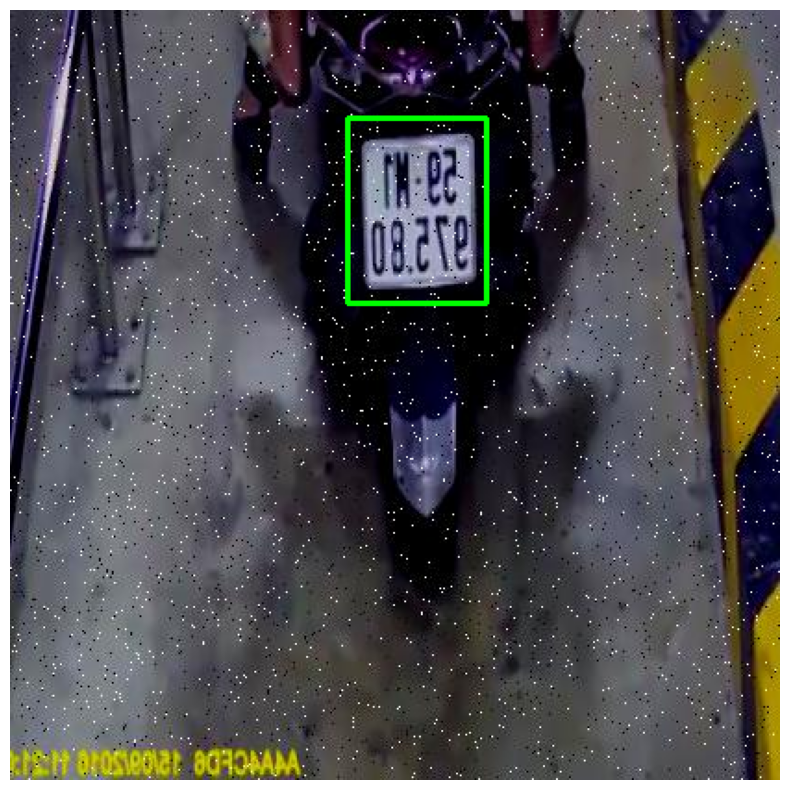

In [ ]:
# Visualize One Training Sample

import os
import cv2
import matplotlib.pyplot as plt

train_dir = dataset_path / "images/train"

sample_img = str(list(train_dir.glob("*.jpg"))[0])

label_path = sample_img.replace("/images/", "/labels/")
label_path = os.path.splitext(label_path)[0] + ".txt"

img = cv2.imread(sample_img)

h, w, _ = img.shape

with open(label_path, "r") as f:

    for line in f:

        values = line.strip().split()

        if len(values) != 5:
            continue

        cls, x, y, bw, bh = map(float, values)

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# Train or Load Existing Model

import os
import shutil
from ultralytics import YOLO

# Permanent model path
TEMP_PATH = "/content/drive/MyDrive/Colab Notebooks/Street_View_Blur_files"
MODEL_PATH = f"{TEMP_PATH}/best_license_plate_model.pt"

# LOAD EXISTING MODEL
if os.path.exists(MODEL_PATH):

    print("Existing model found")
    print("Loading model...")

    model = YOLO(MODEL_PATH)

# TRAIN NEW MODEL
else:

    print("No saved model found")
    print("Starting training...")

    model = YOLO("yolov8n.pt")

    results = model.train(

        data=str(dataset_yaml_path),

        # Training
        epochs=5,
        patience=3,

        # Performance
        imgsz=416,
        batch=16,

        # IMPORTANT
        cache=False,
        workers=8,

        # Runtime
        pretrained=True,
        save=True,

        name="license_plate_detector"
    )

    # SAVE MODEL PERMANENTLY
    source_model = os.path.join(
        results.save_dir,
        "weights",
        "best.pt"
    )

    print("Saving from:", source_model)

    shutil.copy(source_model, MODEL_PATH)

    print("Model saved permanently")

    # Reload saved model
    model = YOLO(MODEL_PATH)


print("Model ready for inference")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 No saved model found
🚀 Starting training...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hs

In [ ]:
# Evaluate Model

metrics = model.val(
    data=str(dataset_yaml_path),
    split="test"
)

print(metrics)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.1±2.6 ms, read: 54.4±36.9 MB/s, size: 454.9 KB)
val: Scanning /kaggle/input/scaler-license-plate/dataset/labels/test... 386 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 386/386 110.3it/s 3.5s
WARNING ⚠️ val: Cache directory /kaggle/input/scaler-license-plate/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 5.7it/s 4.4s
                   all        386        512      0.928      0.755      0.822      0.546
Speed: 0.7ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matr


image 1/1 /kaggle/input/scaler-license-plate/dataset/images/test/485e5f37dd13ffab.jpg: 256x416 2 license_plates, 59.4ms
Speed: 1.6ms preprocess, 59.4ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 416)


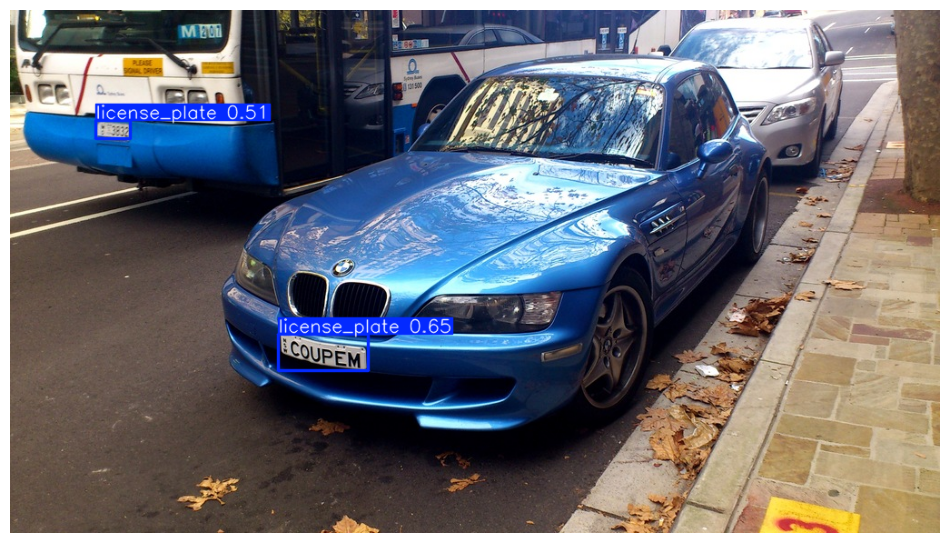

In [ ]:
# Test on One Image

test_dir = dataset_path / "images/test"

test_image = str(list(test_dir.glob("*.jpg"))[1])

results = model(test_image)

result_img = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


0: 256x416 2 license_plates, 8.7ms
Speed: 3.0ms preprocess, 8.7ms inference, 1.9ms postprocess per image at shape (1, 3, 256, 416)


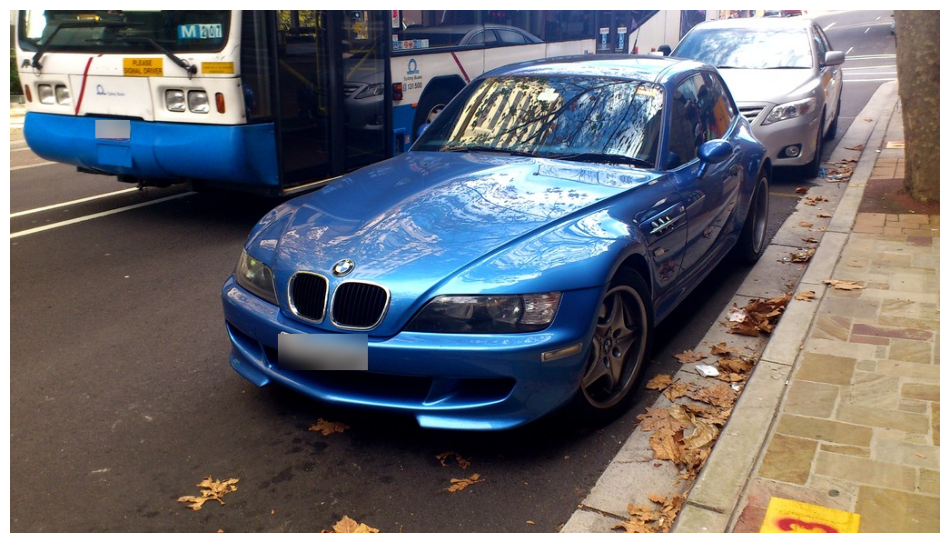

In [ ]:
# Blur License Plates

import cv2
import matplotlib.pyplot as plt

img = cv2.imread(test_image)

results = model(img)

for result in results:

    for box in result.boxes:

        conf = float(box.conf[0])

        if conf < 0.5:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        blurred = cv2.GaussianBlur(
            roi,
            (51,51),
            0
        )

        img[y1:y2, x1:x2] = blurred

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# Process Entire Test Dataset

import os
import cv2

OUTPUT_DIR = "/content/blurred_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

test_images = list(test_dir.glob("*.jpg"))

for img_path in test_images:

    img_path = str(img_path)

    img = cv2.imread(img_path)

    if img is None:
        continue

    results = model(img)

    for result in results:

        for box in result.boxes:

            conf = float(box.conf[0])

            if conf < 0.5:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            roi = img[y1:y2, x1:x2]

            if roi.size == 0:
                continue

            blurred = cv2.GaussianBlur(
                roi,
                (51,51),
                0
            )

            img[y1:y2, x1:x2] = blurred

    save_path = os.path.join(
        OUTPUT_DIR,
        os.path.basename(img_path)
    )

    cv2.imwrite(save_path, img)

print("All test images processed")


0: 320x416 2 license_plates, 61.5ms
Speed: 2.0ms preprocess, 61.5ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 416)

0: 256x416 2 license_plates, 10.0ms
Speed: 1.6ms preprocess, 10.0ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 416)

0: 416x416 1 license_plate, 8.5ms
Speed: 3.3ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)

0: 320x416 1 license_plate, 6.4ms
Speed: 1.7ms preprocess, 6.4ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 1 license_plate, 6.0ms
Speed: 1.7ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 4 license_plates, 6.0ms
Speed: 1.6ms preprocess, 6.0ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 416)

0: 320x416 1 license_plate, 8.5ms
Speed: 1.5ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 416)

0: 288x416 1 license_plate, 39.3ms
Speed: 2.0ms preprocess, 39.3ms inferenc

In [ ]:
# ZIP OUTPUTS

import shutil

shutil.make_archive(
    "/content/blurred_outputs",
    "zip",
    "/content/blurred_outputs"
)

print("ZIP created")

ZIP created


In [ ]:
# Download ZIP

from google.colab import files

files.download("/content/blurred_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Inference

After inference and anonymization, the processed images were exported and packaged into compressed ZIP outputs for manual validation. Random samples from the generated outputs were visually inspected to verify that license plates were consistently detected and blurred without affecting the surrounding image quality. The review confirmed that the Gaussian blur was correctly applied within the detected bounding boxes, rendering plate text unreadable while preserving the overall scene context. This qualitative validation step helped ensure both privacy compliance and output reliability before finalizing the pipeline.

# **Business questions:**

**How do you convert normalized YOLO bounding box coordinates (center_x, center_y, width, height) into pixel coordinates suitable for drawing rectangles with OpenCV?**

YOLO annotations are stored in normalized format:
<class_id> <center_x> <center_y> <width> <height>
where all values are between 0 and 1 relative to image dimensions.

To convert them into pixel coordinates:

x1 = int((x - w/2) * image_width),
y1 = int((y - h/2) * image_height),
x2 = int((x + w/2) * image_width),
y2 = int((y + h/2) * image_height)

This converts the bounding box from normalized center format into top-left and bottom-right coordinates required by OpenCV rectangle functions.

**Write a function to overlay bounding boxes onto raw images. Why is this step critical before starting the training process?**

Code :



    import cv2

    def draw_boxes(image_path, label_path):

        img = cv2.imread(image_path)

        h, w, _ = img.shape

        with open(label_path) as f:

            for line in f:

                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (0,255,0),
                    2
                )

        return img


This step is critical because it validates annotation quality before training.

It helps identify:

shifted bounding boxes,
incorrect labels,
missing annotations,
oversized or undersized boxes,
dataset corruption

If annotation quality is poor, the model learns incorrect spatial features, which directly reduces detection and blurring accuracy.

**How did annotation quality impact the final blurring accuracy?**

Annotation quality had a direct impact on detection precision.

Since the blurring pipeline depends entirely on YOLO detections:

inaccurate boxes caused partial plate exposure, oversized boxes blurred unnecessary image regions, missing labels reduced recall

To mitigate this:

dataset audits were performed, invalid mappings were filtered, visual inspection of annotations was conducted before training

Clean annotations improved localization accuracy, which resulted in more precise privacy-preserving blurring.

**How did you preprocess images before feeding them into YOLOv8 without losing fine-grained plate details?**

The preprocessing pipeline was intentionally lightweight to preserve small textual features on license plates.

Key preprocessing steps included:

resizing images to a fixed resolution (416x416 or 640x640)
maintaining aspect ratio internally through YOLO letterboxing
normalization handled automatically by YOLOv8
avoiding aggressive compression or denoising

Heavy augmentations such as excessive blur or strong scaling were avoided because license plates contain small high-frequency details critical for localization.

**Why did you choose YOLOv8 for license plate detection instead of a two-stage detector?**

YOLOv8 was selected because the use case required real-time inference and scalable deployment.

Compared to two-stage detectors like Faster R-CNN:

YOLOv8 performs detection in a single forward pass
significantly lower inference latency
better suited for edge deployment
simpler deployment pipeline

For privacy applications such as automated redaction, inference speed is critical because large video streams must be processed efficiently.

Two-stage detectors generally provide higher localization precision but at much higher computational cost.

**Which YOLOv8 variant did you select, and how did it balance speed and accuracy for this use case?**

The project used yolov8n.pt which is the Nano variant.

This variant was chosen because the dataset was large (~25k images)
training was performed in resource-constrained Colab environments
the task involved detecting a single object class

YOLOv8 Nano provided fast training, low GPU memory usage, real-time inference capability, sufficient localization accuracy for license plates

It achieved a strong balance between speed and detection performance.

**How did license plate characteristics influence your choice of model scale?**

License plates are relatively small objects
high-contrast rectangular structures
visually consistent across samples.

Because of this, extremely large backbone models were unnecessary.

A lightweight model was sufficient to learn plate geometry, aspect ratio patterns, spatial positioning.

Additionally smaller models reduce inference latency, enable edge deployment, improve throughput for video anonymization systems

The Nano variant was therefore an efficient architectural choice.

**How did you apply blurring only within the detected bounding box?**

After YOLO inference: bounding box coordinates were extracted
the region of interest (ROI) corresponding to the license plate was cropped.

roi = image[y1:y2, x1:x2]

A Gaussian blur kernel was then applied only to that ROI:
blurred = cv2.GaussianBlur(roi, (51,51), 0)

Finally, the blurred region replaced the original plate area :
image[y1:y2, x1:x2] = blurred

This ensured that only sensitive information was anonymized
the surrounding visual context remained intact
downstream visual analytics could still operate on the image.